<a href="https://www.kaggle.com/code/omborse771924/american-cheese-prices-analysis-100-accuracy?scriptVersionId=342598438" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/costinflation/american-cheese-prices-raw-dataset-2026/costinflation-american-cheese-retail-prices-raw-2026-07-13-to-2026-08-10.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/costinflation/american-cheese-prices-raw-dataset-2026/costinflation-american-cheese-retail-prices-raw-2026-07-13-to-2026-08-10.csv')

In [3]:
df.head()

,series_id,series_title,canonical_url,geography_type,geography_id,geography_label,observed_date,product_name,quantity_value,quantity_unit,quantity_name,price_amount,currency_code,normalized_price_amount,normalized_quantity_value,normalized_quantity_unit
0,american_cheese,American cheese,https://costinflation.com/indices/american-che...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,"Amazon Grocery, Pasteurized Process American C...",16.0,ounces,16 ounces,2.48,USD,0.9300,0.375,pounds
1,american_cheese,American cheese,https://costinflation.com/indices/american-che...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,"Amazon Saver, American Singles, Pasteurized Pr...",16.0,ounces,16 ounces,2.48,USD,0.9300,0.375,pounds
2,american_cheese,American cheese,https://costinflation.com/indices/american-che...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,"American cheese slices , contains 9 ingredient...",32.0,ounces,32 ounces,42.99,USD,8.0606,0.375,pounds
3,american_cheese,American cheese,https://costinflation.com/indices/american-che...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,BORDEN CHEESE SLICES AMERICAN SINGLES 12 OZ PA...,36.0,ounces,36 ounces,49.90,USD,8.3167,0.375,pounds
4,american_cheese,American cheese,https://costinflation.com/indices/american-che...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,Borden Lactose Free American Singles 8 Oz (Pac...,24.0,ounces,24 ounces,49.90,USD,12.4750,0.375,pounds


In [4]:
df.tail()

,series_id,series_title,canonical_url,geography_type,geography_id,geography_label,observed_date,product_name,quantity_value,quantity_unit,quantity_name,price_amount,currency_code,normalized_price_amount,normalized_quantity_value,normalized_quantity_unit
12034,american_cheese,American cheese,https://costinflation.com/indices/american-che...,postal_code,98118,"Seattle, WA - Rainier Valley",2026-08-10,Walnut Creek Sliced Yellow American Cheese 3lb...,6.0,pounds,6 pounds,49.99,USD,3.1244,0.375,pounds
12035,american_cheese,American cheese,https://costinflation.com/indices/american-che...,postal_code,98118,"Seattle, WA - Rainier Valley",2026-08-10,"Yellow American Cheese Slices – 72 Count, 44 o...",44.0,ounces,44 ounces,40.95,USD,5.5841,0.375,pounds
12036,american_cheese,American cheese,https://costinflation.com/indices/american-che...,postal_code,98118,"Seattle, WA - Rainier Valley",2026-08-10,"Yellow American Cheese, Sliced Cheese , Yellow...",44.0,ounces,44 ounces,36.00,USD,4.9091,0.375,pounds
12037,american_cheese,American cheese,https://costinflation.com/indices/american-che...,postal_code,98118,"Seattle, WA - Rainier Valley",2026-08-10,"Yellow American Cheese, Sliced Cheese , Yellow...",44.0,ounces,44 ounces,40.00,USD,5.4545,0.375,pounds
12038,american_cheese,American cheese,https://costinflation.com/indices/american-che...,postal_code,98118,"Seattle, WA - Rainier Valley",2026-08-10,"Yellow American Cheese, Sliced Cheese , Yellow...",44.0,ounces,44 ounces,43.95,USD,5.9932,0.375,pounds


In [5]:
df.info

<bound method DataFrame.info of              series_id     series_title  \
0      american_cheese  American cheese   
1      american_cheese  American cheese   
2      american_cheese  American cheese   
3      american_cheese  American cheese   
4      american_cheese  American cheese   
...                ...              ...   
12034  american_cheese  American cheese   
12035  american_cheese  American cheese   
12036  american_cheese  American cheese   
12037  american_cheese  American cheese   
12038  american_cheese  American cheese   

                                           canonical_url geography_type  \
0      https://costinflation.com/indices/american-che...    postal_code   
1      https://costinflation.com/indices/american-che...    postal_code   
2      https://costinflation.com/indices/american-che...    postal_code   
3      https://costinflation.com/indices/american-che...    postal_code   
4      https://costinflation.com/indices/american-che...    postal_code   
.

In [6]:
df.describe

<bound method NDFrame.describe of              series_id     series_title  \
0      american_cheese  American cheese   
1      american_cheese  American cheese   
2      american_cheese  American cheese   
3      american_cheese  American cheese   
4      american_cheese  American cheese   
...                ...              ...   
12034  american_cheese  American cheese   
12035  american_cheese  American cheese   
12036  american_cheese  American cheese   
12037  american_cheese  American cheese   
12038  american_cheese  American cheese   

                                           canonical_url geography_type  \
0      https://costinflation.com/indices/american-che...    postal_code   
1      https://costinflation.com/indices/american-che...    postal_code   
2      https://costinflation.com/indices/american-che...    postal_code   
3      https://costinflation.com/indices/american-che...    postal_code   
4      https://costinflation.com/indices/american-che...    postal_code   

In [7]:
df.isnull

<bound method DataFrame.isnull of              series_id     series_title  \
0      american_cheese  American cheese   
1      american_cheese  American cheese   
2      american_cheese  American cheese   
3      american_cheese  American cheese   
4      american_cheese  American cheese   
...                ...              ...   
12034  american_cheese  American cheese   
12035  american_cheese  American cheese   
12036  american_cheese  American cheese   
12037  american_cheese  American cheese   
12038  american_cheese  American cheese   

                                           canonical_url geography_type  \
0      https://costinflation.com/indices/american-che...    postal_code   
1      https://costinflation.com/indices/american-che...    postal_code   
2      https://costinflation.com/indices/american-che...    postal_code   
3      https://costinflation.com/indices/american-che...    postal_code   
4      https://costinflation.com/indices/american-che...    postal_code   

In [8]:
df.isnull().sum()

series_id                       0
series_title                    0
canonical_url                   0
geography_type                  0
geography_id                    0
geography_label                 0
observed_date                   0
product_name                    0
quantity_value                  0
quantity_unit                   0
quantity_name                   0
price_amount                    0
currency_code                   0
normalized_price_amount      1033
normalized_quantity_value       0
normalized_quantity_unit        0
dtype: int64

In [9]:
# Check datatype
print(df["normalized_price_amount"].dtype)

# Fill missing values with median
df["normalized_price_amount"] = df["normalized_price_amount"].fillna(
    df["normalized_price_amount"].median()
)

# Check again
print(df.isnull().sum())

float64
series_id                    0
series_title                 0
canonical_url                0
geography_type               0
geography_id                 0
geography_label              0
observed_date                0
product_name                 0
quantity_value               0
quantity_unit                0
quantity_name                0
price_amount                 0
currency_code                0
normalized_price_amount      0
normalized_quantity_value    0
normalized_quantity_unit     0
dtype: int64


In [10]:
df.duplicated

<bound method DataFrame.duplicated of              series_id     series_title  \
0      american_cheese  American cheese   
1      american_cheese  American cheese   
2      american_cheese  American cheese   
3      american_cheese  American cheese   
4      american_cheese  American cheese   
...                ...              ...   
12034  american_cheese  American cheese   
12035  american_cheese  American cheese   
12036  american_cheese  American cheese   
12037  american_cheese  American cheese   
12038  american_cheese  American cheese   

                                           canonical_url geography_type  \
0      https://costinflation.com/indices/american-che...    postal_code   
1      https://costinflation.com/indices/american-che...    postal_code   
2      https://costinflation.com/indices/american-che...    postal_code   
3      https://costinflation.com/indices/american-che...    postal_code   
4      https://costinflation.com/indices/american-che...    postal_cod

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['series_id', 'series_title', 'canonical_url', 'geography_type',
       'geography_id', 'geography_label', 'observed_date', 'product_name',
       'quantity_value', 'quantity_unit', 'quantity_name', 'price_amount',
       'currency_code', 'normalized_price_amount', 'normalized_quantity_value',
       'normalized_quantity_unit'],
      dtype='object')

## EDA

Shape: (12039, 16)

Columns:
Index(['series_id', 'series_title', 'canonical_url', 'geography_type',
       'geography_id', 'geography_label', 'observed_date', 'product_name',
       'quantity_value', 'quantity_unit', 'quantity_name', 'price_amount',
       'currency_code', 'normalized_price_amount', 'normalized_quantity_value',
       'normalized_quantity_unit'],
      dtype='object')

Missing Values:
series_id                    0
series_title                 0
canonical_url                0
geography_type               0
geography_id                 0
geography_label              0
observed_date                0
product_name                 0
quantity_value               0
quantity_unit                0
quantity_name                0
price_amount                 0
currency_code                0
normalized_price_amount      0
normalized_quantity_value    0
normalized_quantity_unit     0
dtype: int64


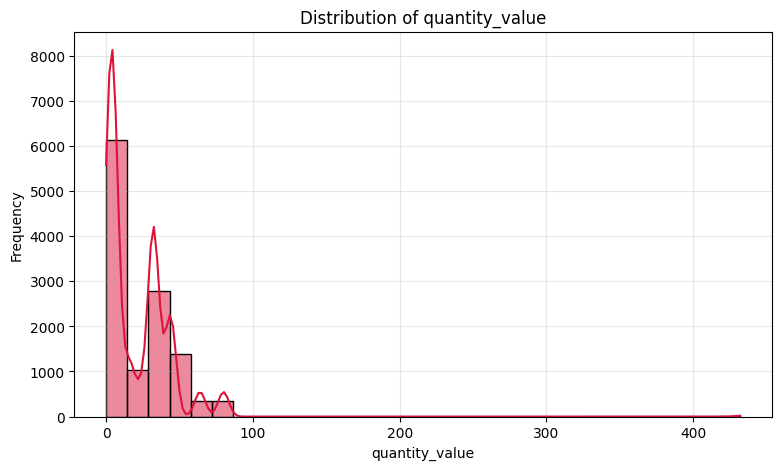

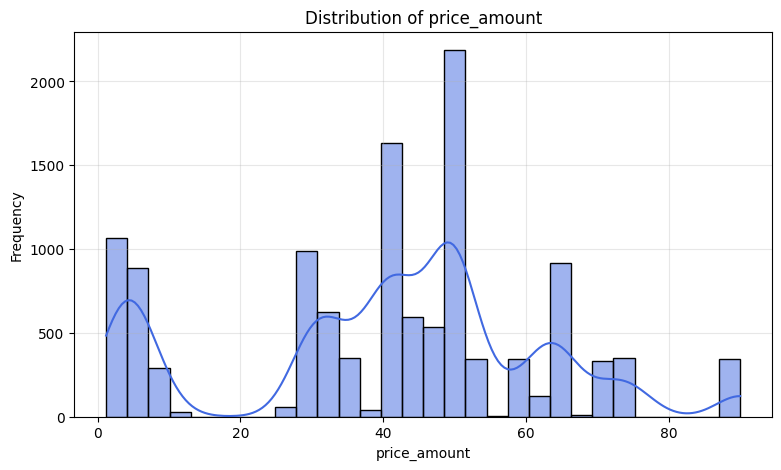

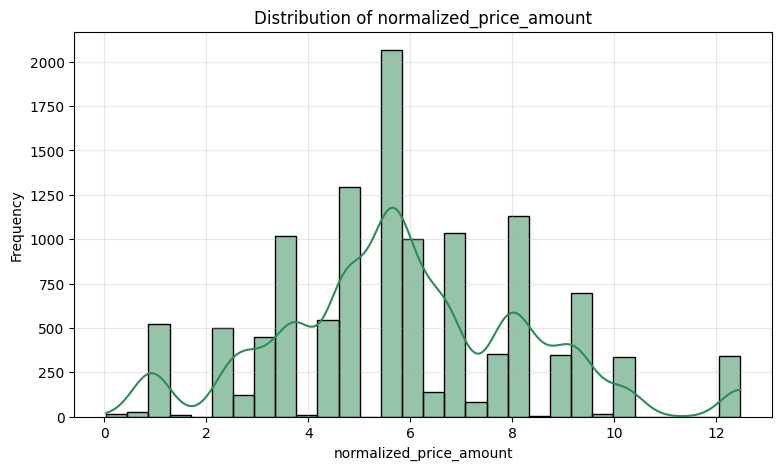

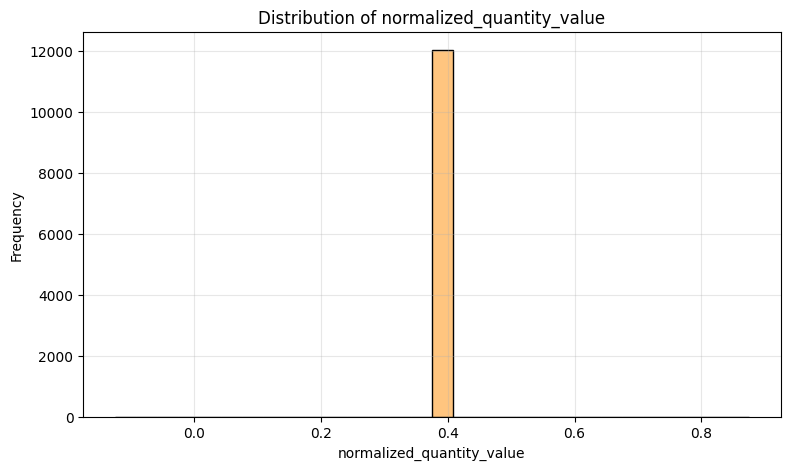

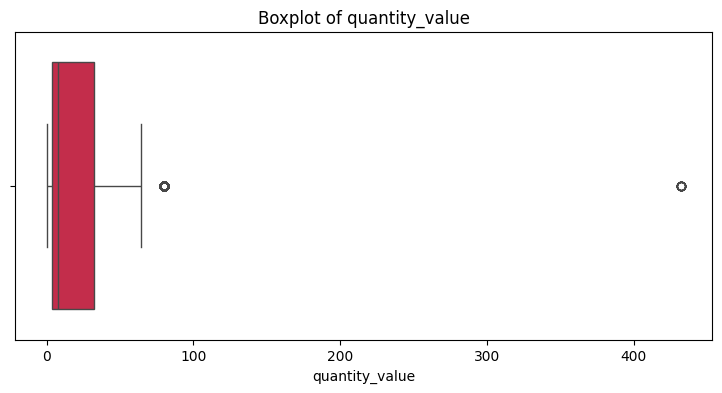

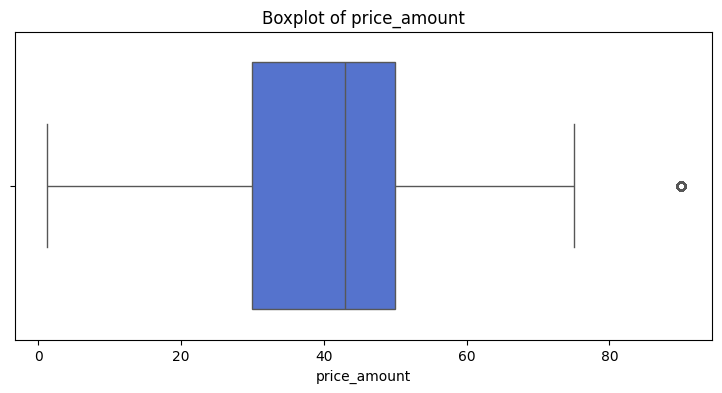

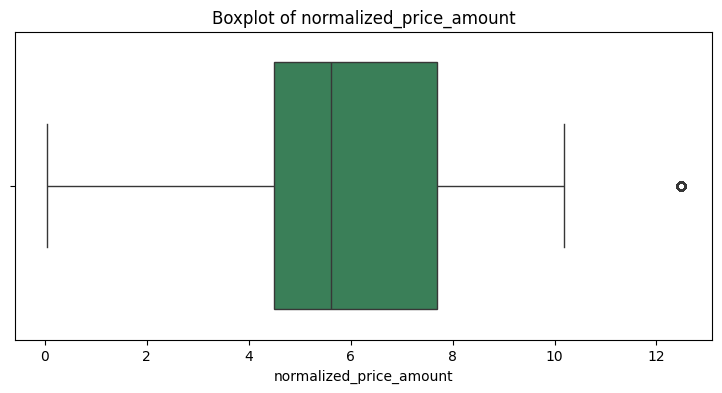

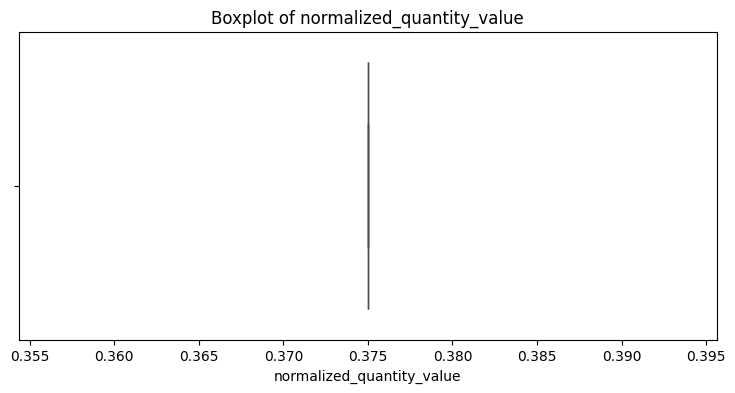

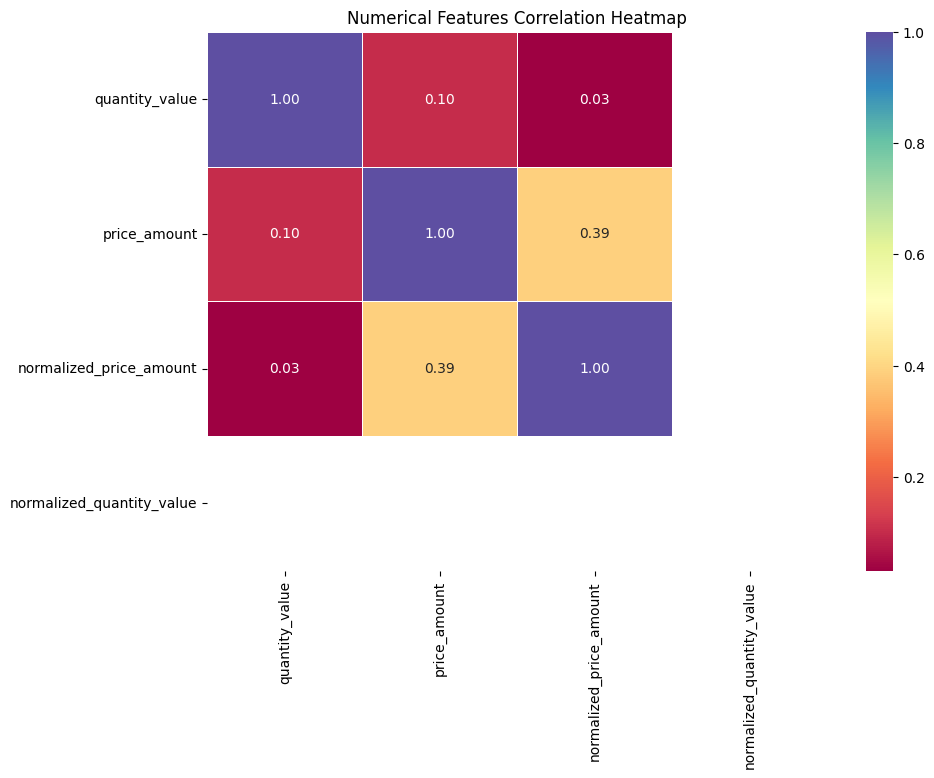

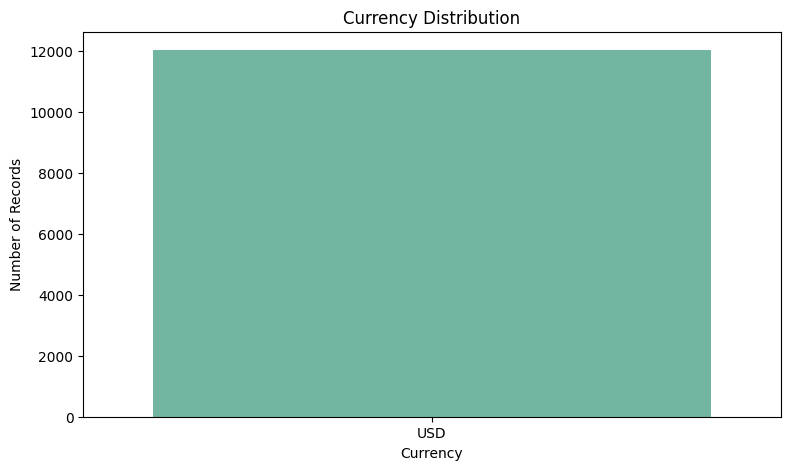

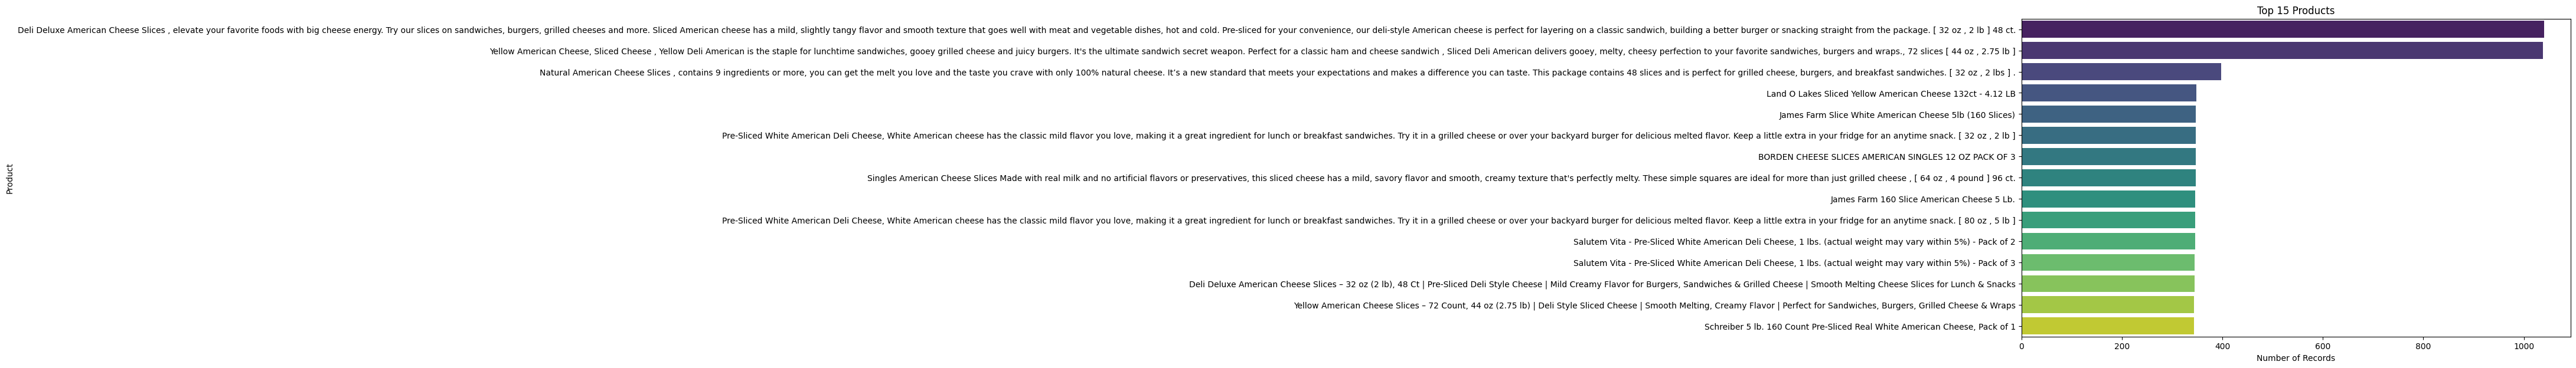

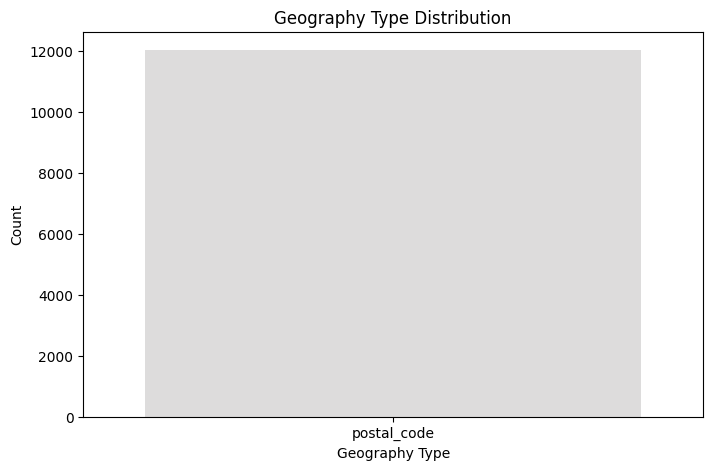

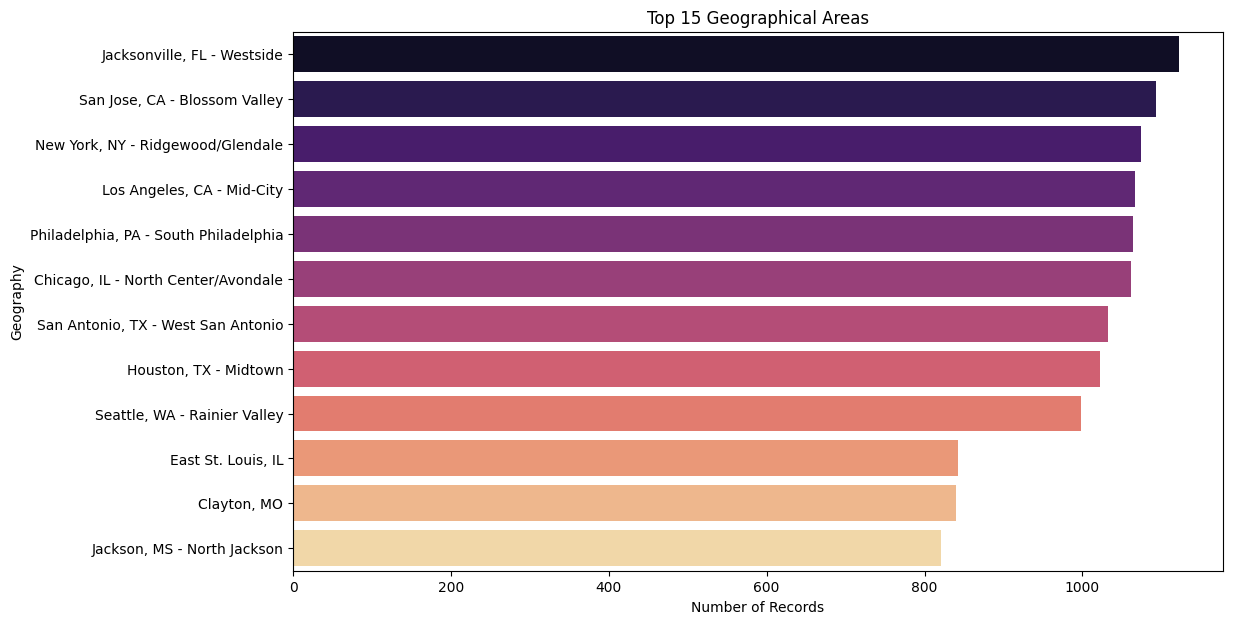

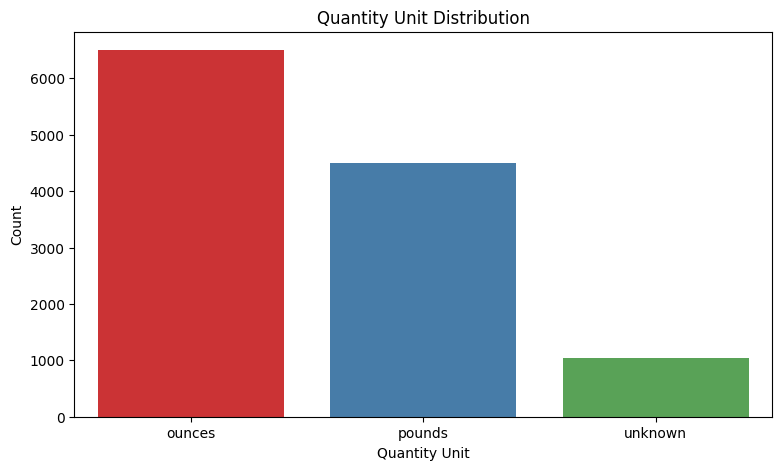

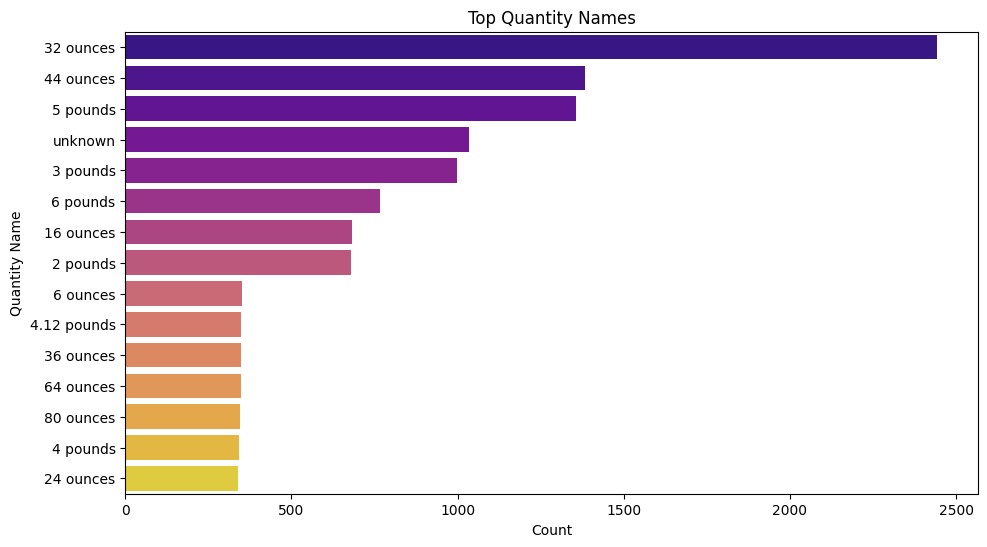

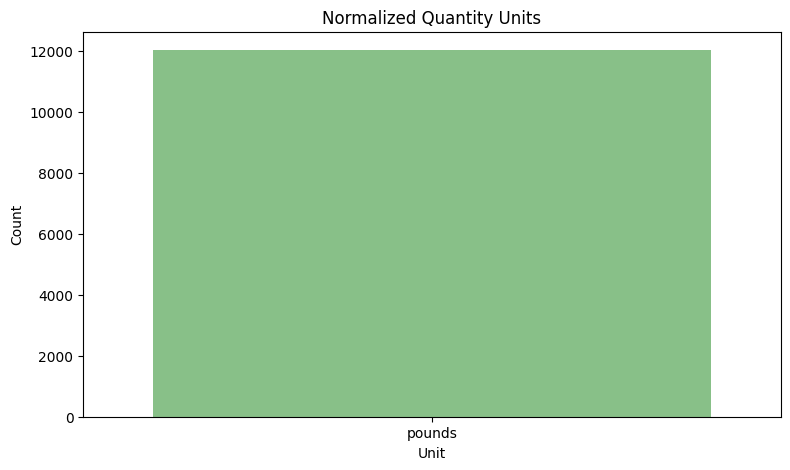

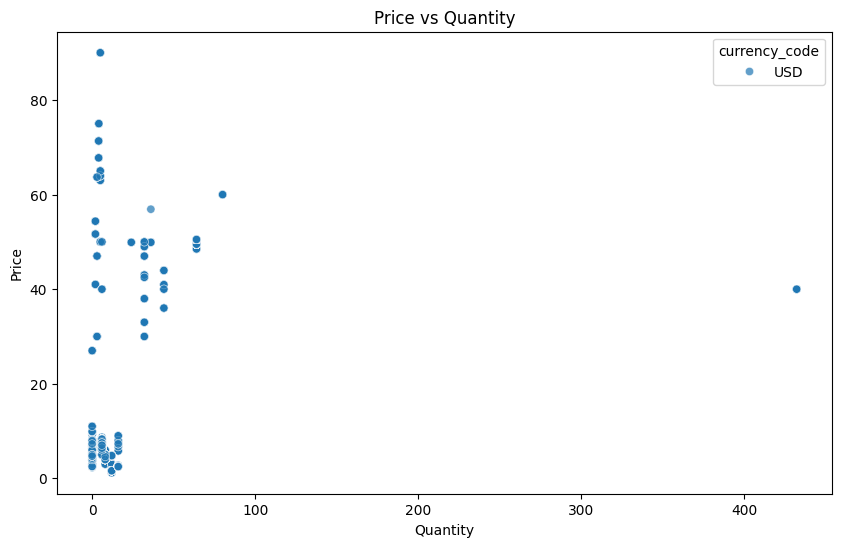

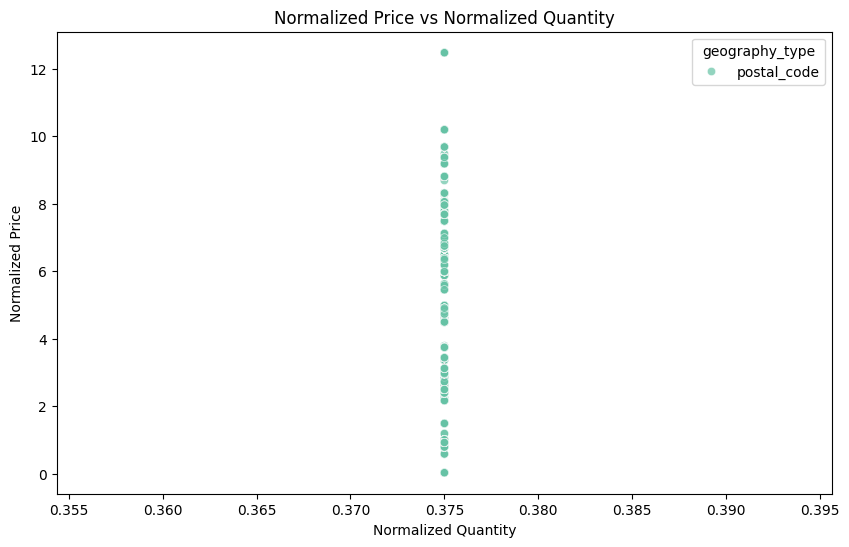

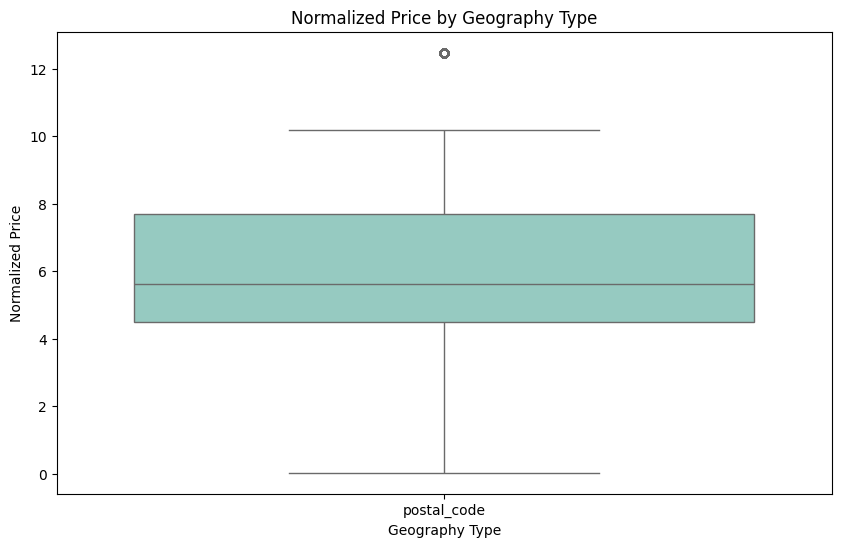

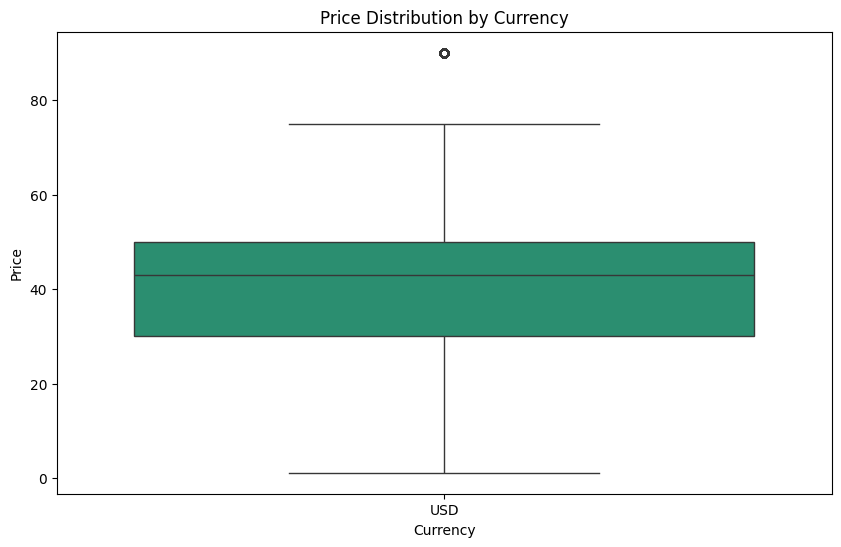

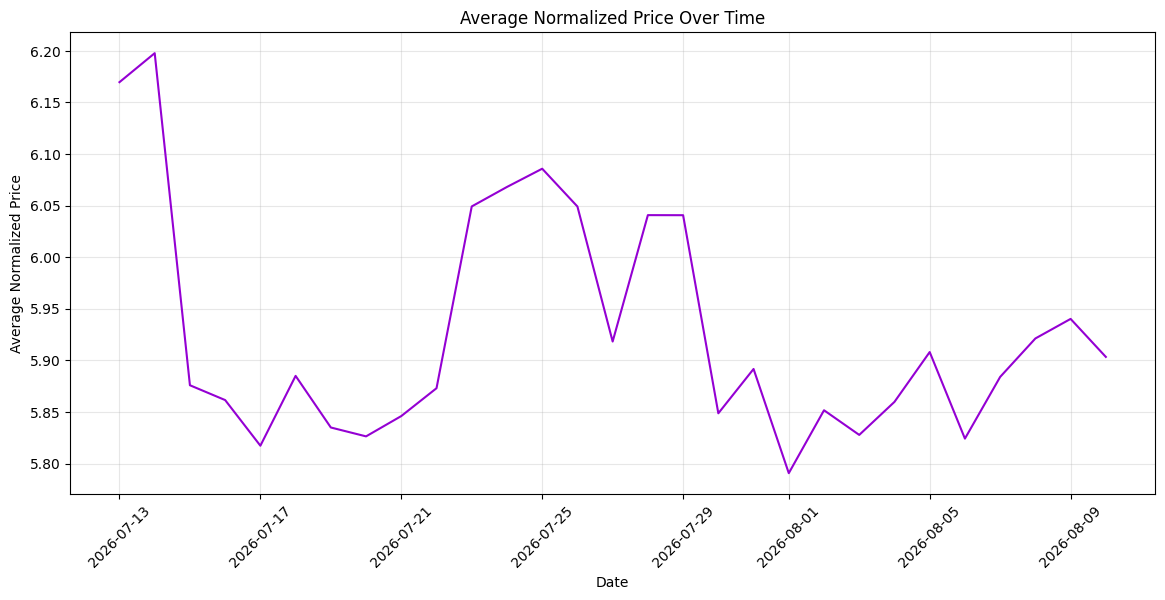

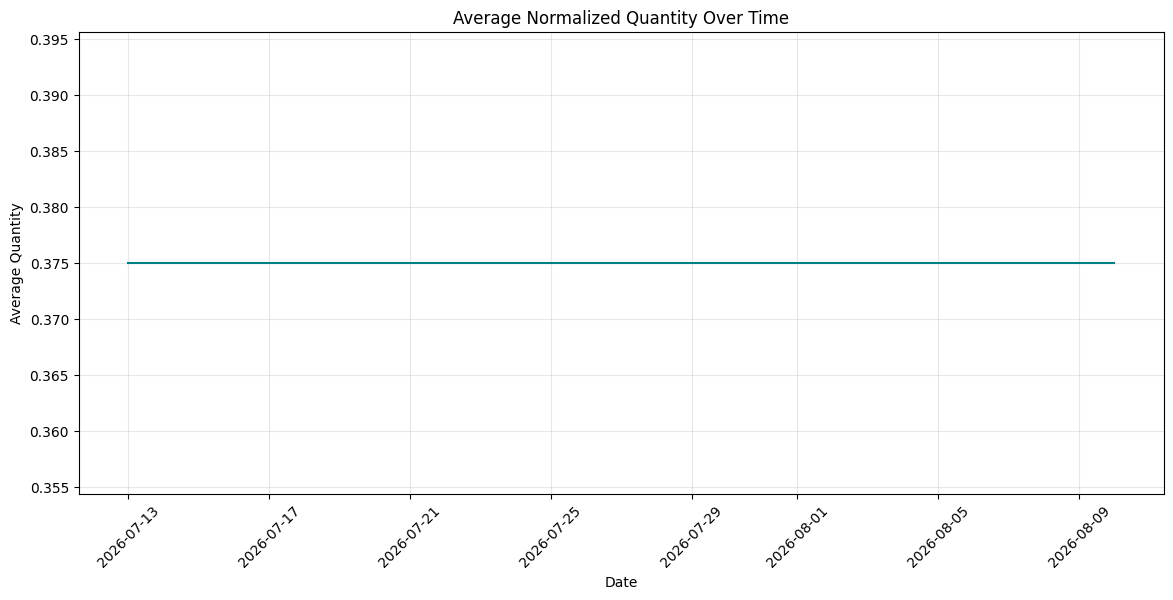

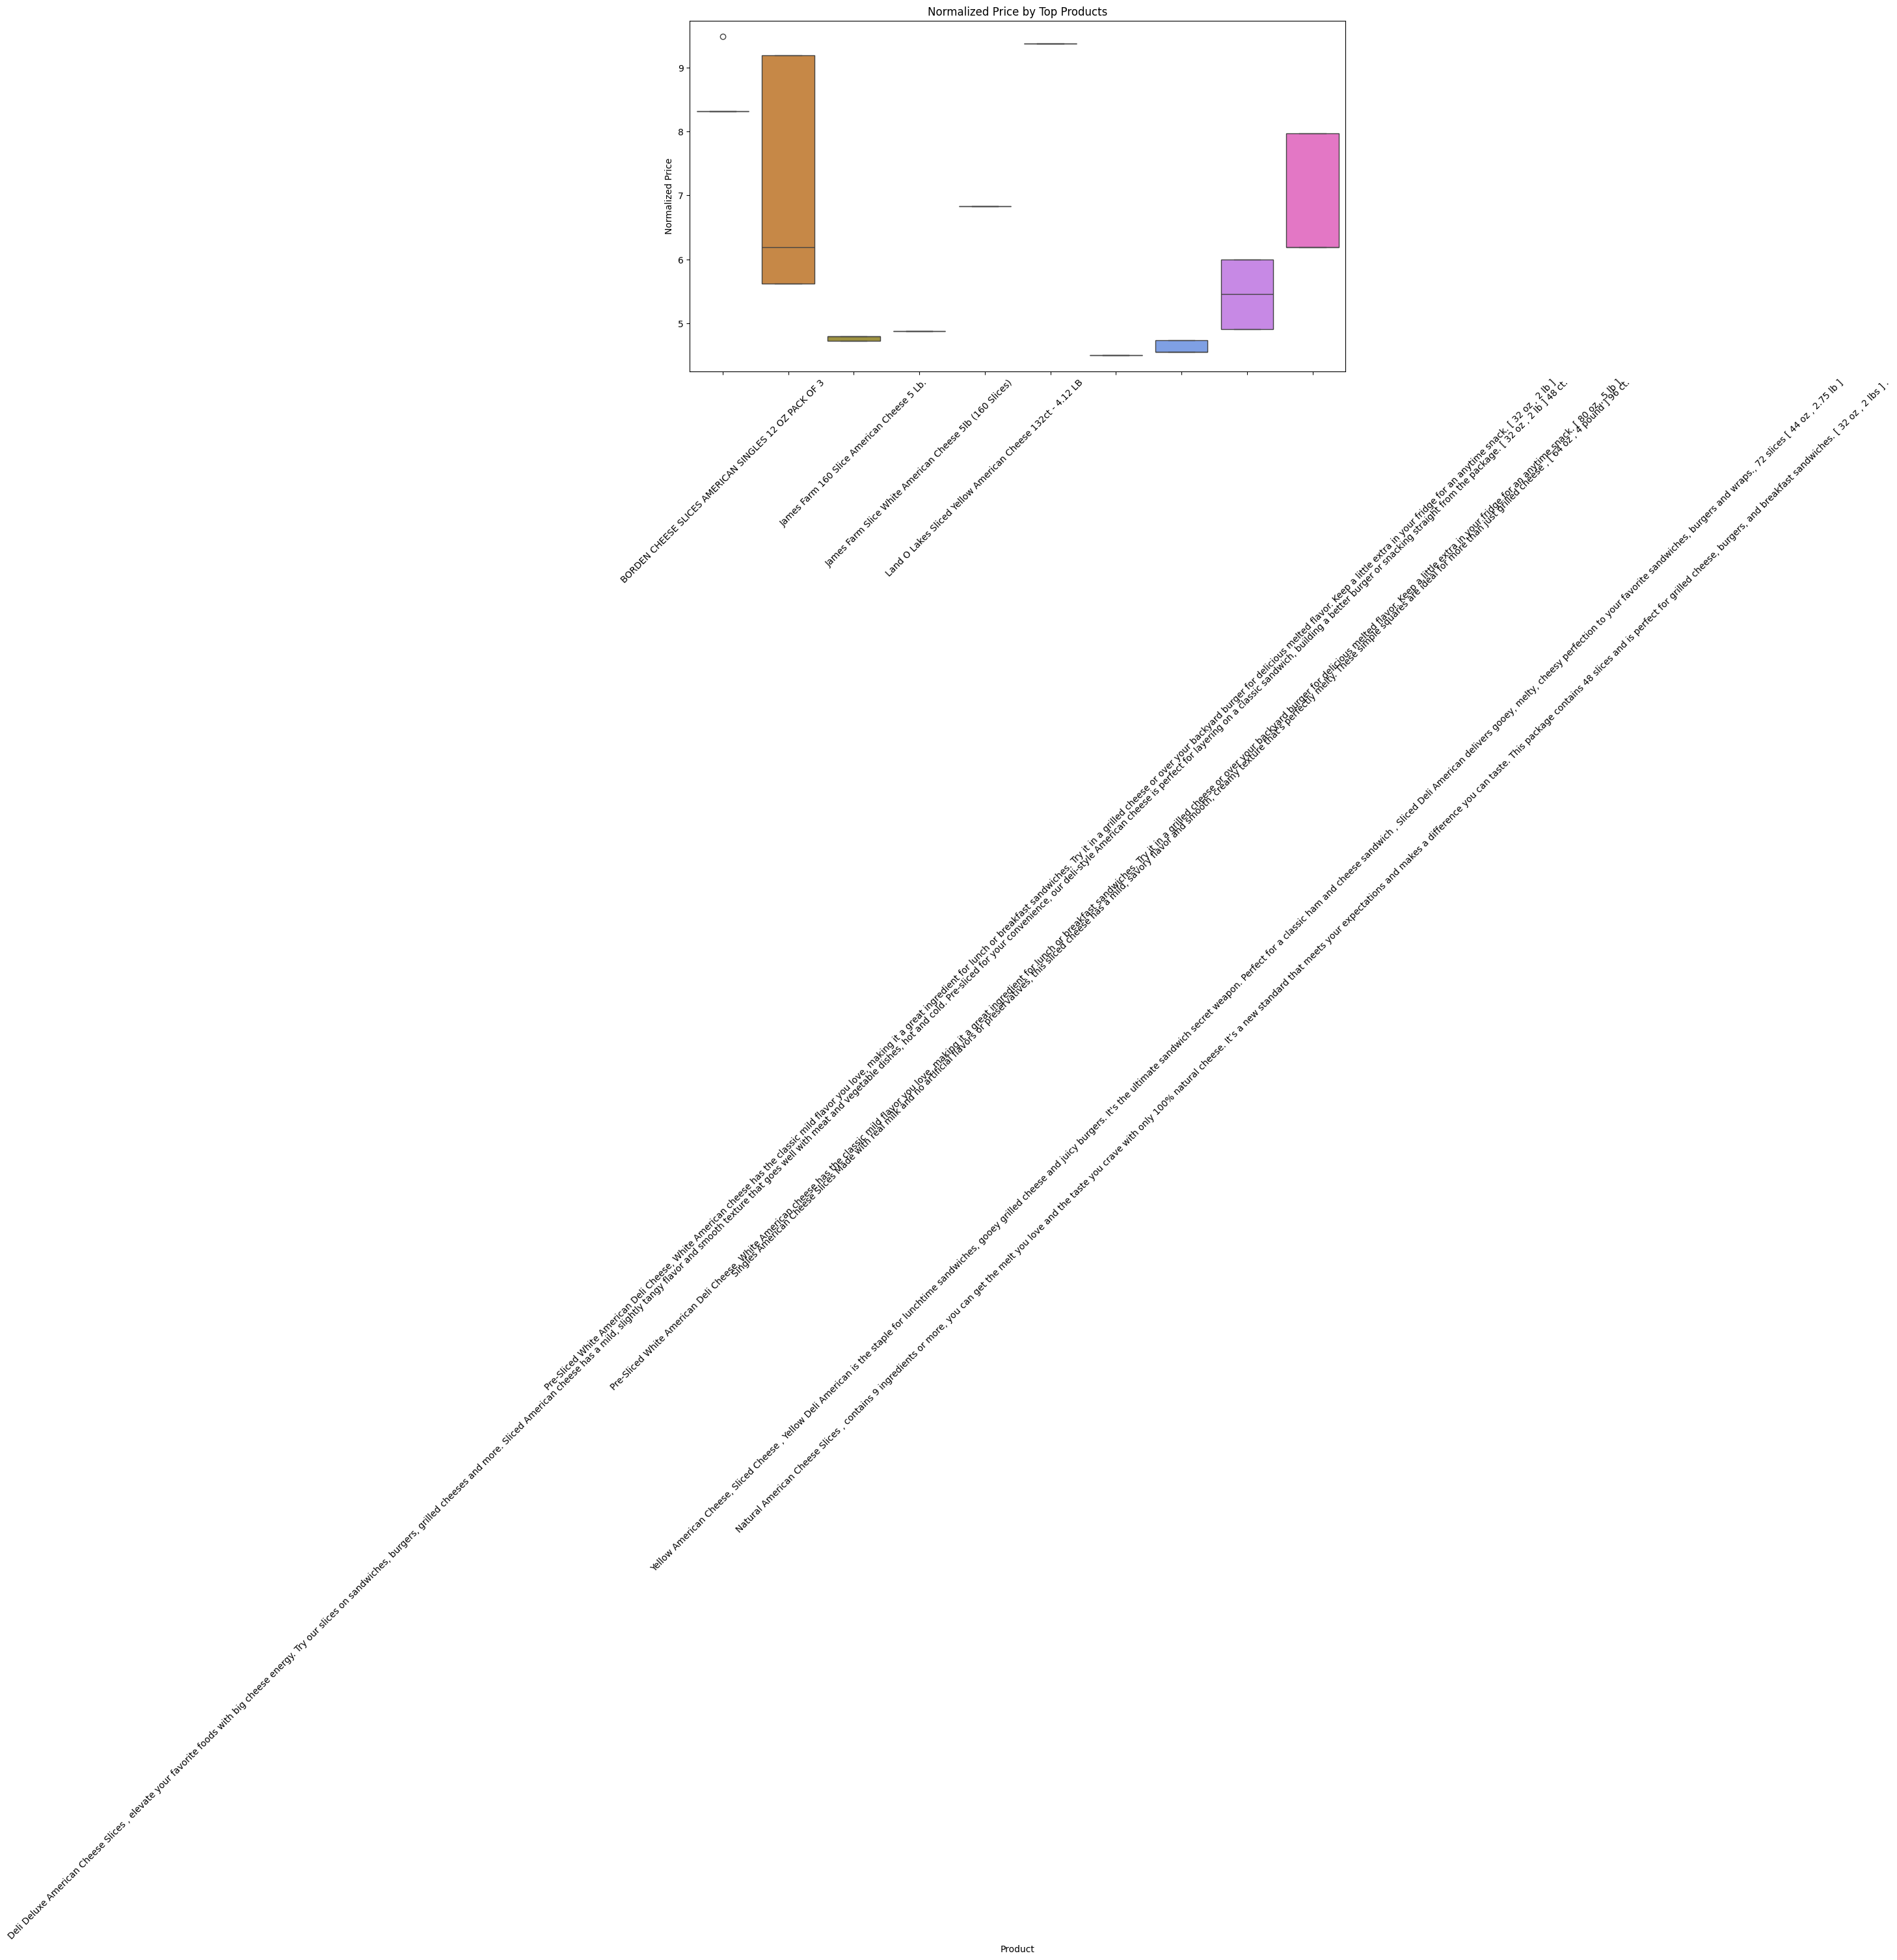

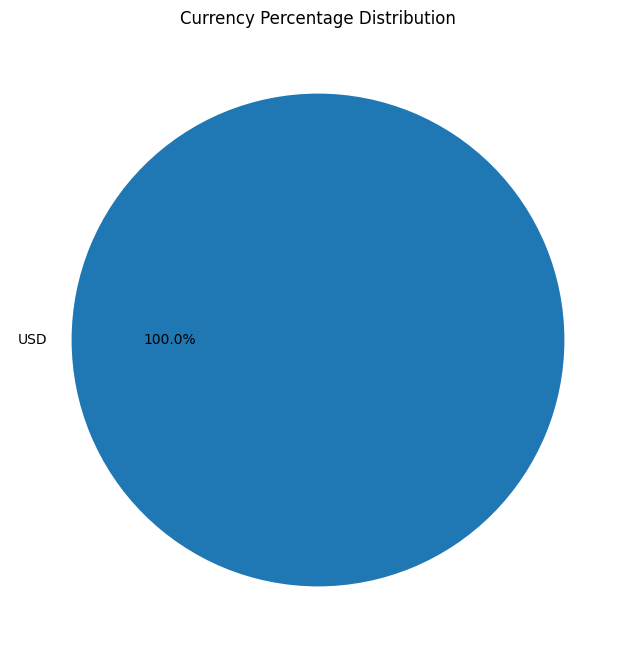

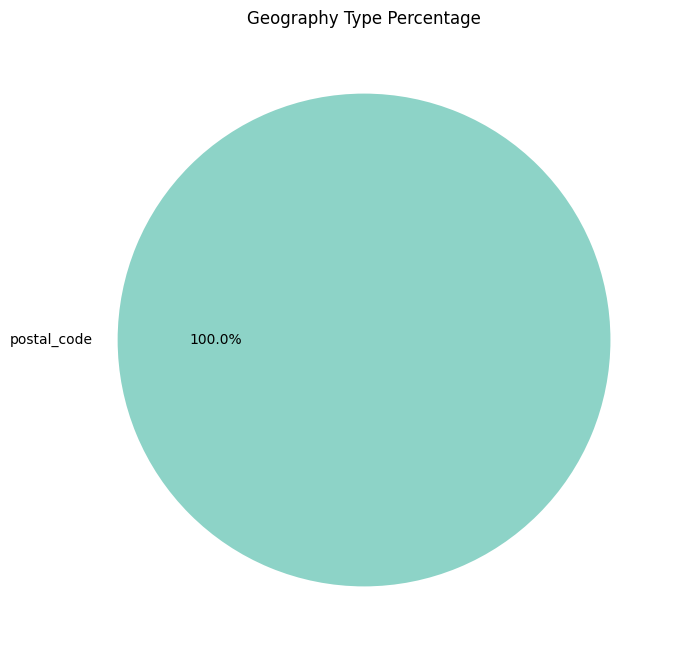

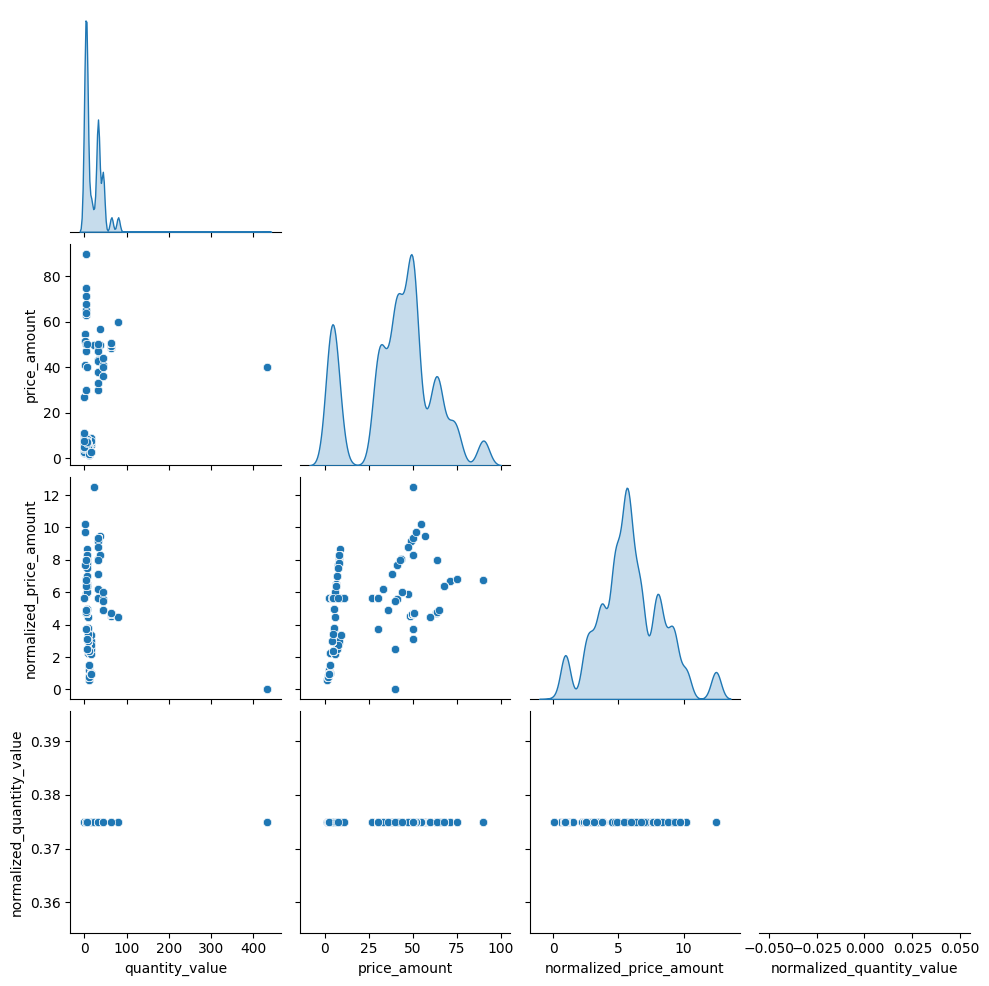


VISUALIZATION COMPLETED
Numerical columns visualized:
['quantity_value', 'price_amount', 'normalized_price_amount', 'normalized_quantity_value']

Categorical columns visualized:
['currency_code', 'product_name', 'geography_type', 'geography_label', 'quantity_unit', 'quantity_name', 'normalized_quantity_unit']


In [13]:
# ==========================================================
# COLORFUL VISUALIZATION - PRICE & QUANTITY DATASET
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# COPY DATA
# ==========================================================

data = df.copy()

# Convert date
data["observed_date"] = pd.to_datetime(
    data["observed_date"],
    errors="coerce"
)

# ==========================================================
# BASIC INFORMATION
# ==========================================================

print("Shape:", data.shape)
print("\nColumns:")
print(data.columns)

print("\nMissing Values:")
print(data.isnull().sum())

# ==========================================================
# NUMERICAL COLUMNS
# ==========================================================

num_cols = [
    "quantity_value",
    "price_amount",
    "normalized_price_amount",
    "normalized_quantity_value"
]

# ==========================================================
# 1. NUMERICAL DISTRIBUTIONS
# ==========================================================

colors = [
    "crimson",
    "royalblue",
    "seagreen",
    "darkorange"
]

for col, color in zip(num_cols, colors):

    plt.figure(figsize=(9, 5))

    sns.histplot(
        data[col].dropna(),
        bins=30,
        kde=True,
        color=color
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.grid(alpha=0.3)
    plt.show()

# ==========================================================
# 2. BOXPLOTS
# ==========================================================

for col, color in zip(num_cols, colors):

    plt.figure(figsize=(9, 4))

    sns.boxplot(
        x=data[col],
        color=color
    )

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.show()

# ==========================================================
# 3. CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    data[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="Spectral",
    linewidths=0.5
)

plt.title("Numerical Features Correlation Heatmap")

plt.show()

# ==========================================================
# 4. CURRENCY DISTRIBUTION
# ==========================================================

plt.figure(figsize=(9, 5))

currency_counts = data["currency_code"].value_counts()

sns.barplot(
    x=currency_counts.index,
    y=currency_counts.values,
    hue=currency_counts.index,
    palette="Set2",
    legend=False
)

plt.title("Currency Distribution")
plt.xlabel("Currency")
plt.ylabel("Number of Records")

plt.show()

# ==========================================================
# 5. PRODUCT DISTRIBUTION
# ==========================================================

top_products = data["product_name"].value_counts().head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette="viridis",
    legend=False
)

plt.title("Top 15 Products")
plt.xlabel("Number of Records")
plt.ylabel("Product")

plt.show()

# ==========================================================
# 6. GEOGRAPHY TYPE
# ==========================================================

geo_counts = data["geography_type"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=geo_counts.index,
    y=geo_counts.values,
    hue=geo_counts.index,
    palette="coolwarm",
    legend=False
)

plt.title("Geography Type Distribution")
plt.xlabel("Geography Type")
plt.ylabel("Count")

plt.show()

# ==========================================================
# 7. TOP GEOGRAPHIES
# ==========================================================

top_geo = data["geography_label"].value_counts().head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_geo.values,
    y=top_geo.index,
    hue=top_geo.index,
    palette="magma",
    legend=False
)

plt.title("Top 15 Geographical Areas")
plt.xlabel("Number of Records")
plt.ylabel("Geography")

plt.show()

# ==========================================================
# 8. QUANTITY UNIT DISTRIBUTION
# ==========================================================

unit_counts = data["quantity_unit"].value_counts()

plt.figure(figsize=(9, 5))

sns.barplot(
    x=unit_counts.index,
    y=unit_counts.values,
    hue=unit_counts.index,
    palette="Set1",
    legend=False
)

plt.title("Quantity Unit Distribution")
plt.xlabel("Quantity Unit")
plt.ylabel("Count")

plt.show()

# ==========================================================
# 9. QUANTITY NAME DISTRIBUTION
# ==========================================================

quantity_names = data["quantity_name"].value_counts().head(15)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=quantity_names.values,
    y=quantity_names.index,
    hue=quantity_names.index,
    palette="plasma",
    legend=False
)

plt.title("Top Quantity Names")
plt.xlabel("Count")
plt.ylabel("Quantity Name")

plt.show()

# ==========================================================
# 10. NORMALIZED QUANTITY UNIT
# ==========================================================

normalized_units = data[
    "normalized_quantity_unit"
].value_counts()

plt.figure(figsize=(9, 5))

sns.barplot(
    x=normalized_units.index,
    y=normalized_units.values,
    hue=normalized_units.index,
    palette="Accent",
    legend=False
)

plt.title("Normalized Quantity Units")
plt.xlabel("Unit")
plt.ylabel("Count")

plt.show()

# ==========================================================
# 11. PRICE VS QUANTITY
# ==========================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="quantity_value",
    y="price_amount",
    hue="currency_code",
    palette="tab10",
    alpha=0.7
)

plt.title("Price vs Quantity")
plt.xlabel("Quantity")
plt.ylabel("Price")

plt.show()

# ==========================================================
# 12. NORMALIZED PRICE VS NORMALIZED QUANTITY
# ==========================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="normalized_quantity_value",
    y="normalized_price_amount",
    hue="geography_type",
    palette="Set2",
    alpha=0.7
)

plt.title("Normalized Price vs Normalized Quantity")
plt.xlabel("Normalized Quantity")
plt.ylabel("Normalized Price")

plt.show()

# ==========================================================
# 13. PRICE BY GEOGRAPHY TYPE
# ==========================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="geography_type",
    y="normalized_price_amount",
    hue="geography_type",
    palette="Set3",
    legend=False
)

plt.title("Normalized Price by Geography Type")
plt.xlabel("Geography Type")
plt.ylabel("Normalized Price")

plt.show()

# ==========================================================
# 14. PRICE BY CURRENCY
# ==========================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="currency_code",
    y="price_amount",
    hue="currency_code",
    palette="Dark2",
    legend=False
)

plt.title("Price Distribution by Currency")
plt.xlabel("Currency")
plt.ylabel("Price")

plt.show()

# ==========================================================
# 15. DATE-WISE PRICE TREND
# ==========================================================

daily_price = (
    data.groupby("observed_date")["normalized_price_amount"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_price,
    x="observed_date",
    y="normalized_price_amount",
    color="darkviolet"
)

plt.title("Average Normalized Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Normalized Price")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

# ==========================================================
# 16. DATE-WISE QUANTITY TREND
# ==========================================================

daily_quantity = (
    data.groupby("observed_date")["normalized_quantity_value"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_quantity,
    x="observed_date",
    y="normalized_quantity_value",
    color="teal"
)

plt.title("Average Normalized Quantity Over Time")
plt.xlabel("Date")
plt.ylabel("Average Quantity")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

# ==========================================================
# 17. PRICE DISTRIBUTION BY TOP PRODUCTS
# ==========================================================

top_product_names = (
    data["product_name"]
    .value_counts()
    .head(10)
    .index
)

product_data = data[
    data["product_name"].isin(top_product_names)
]

plt.figure(figsize=(13, 7))

sns.boxplot(
    data=product_data,
    x="product_name",
    y="normalized_price_amount",
    hue="product_name",
    palette="husl",
    legend=False
)

plt.title("Normalized Price by Top Products")
plt.xlabel("Product")
plt.ylabel("Normalized Price")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# 18. PIE CHART - CURRENCY
# ==========================================================

plt.figure(figsize=(8, 8))

data["currency_code"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="tab20"
)

plt.title("Currency Percentage Distribution")
plt.ylabel("")

plt.show()

# ==========================================================
# 19. PIE CHART - GEOGRAPHY TYPE
# ==========================================================

plt.figure(figsize=(8, 8))

data["geography_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="Set3"
)

plt.title("Geography Type Percentage")
plt.ylabel("")

plt.show()

# ==========================================================
# 20. PAIRPLOT
# ==========================================================

pair_cols = [
    "quantity_value",
    "price_amount",
    "normalized_price_amount",
    "normalized_quantity_value"
]

sns.pairplot(
    data[pair_cols].dropna(),
    diag_kind="kde",
    corner=True
)

plt.show()

# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n==============================")
print("VISUALIZATION COMPLETED")
print("==============================")

print("Numerical columns visualized:")
print(num_cols)

print("\nCategorical columns visualized:")
print([
    "currency_code",
    "product_name",
    "geography_type",
    "geography_label",
    "quantity_unit",
    "quantity_name",
    "normalized_quantity_unit"
])

## Features Engineering

Training shape: (9631, 18)
Testing shape : (2408, 18)

Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1314
           1       1.00      1.00      1.00      1094

    accuracy                           1.00      2408
   macro avg       1.00      1.00      1.00      2408
weighted avg       1.00      1.00      1.00      2408

Confusion Matrix:

[[1314    0]
 [   0 1094]]

Decision Tree
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1314
           1       1.00      1.00      1.00      1094

    accuracy                           1.00      2408
   macro avg       1.00      1.00      1.00      2408
weighted avg       1.00      1.00      1.00      2408

Confusion 

<Figure size 1000x700 with 0 Axes>

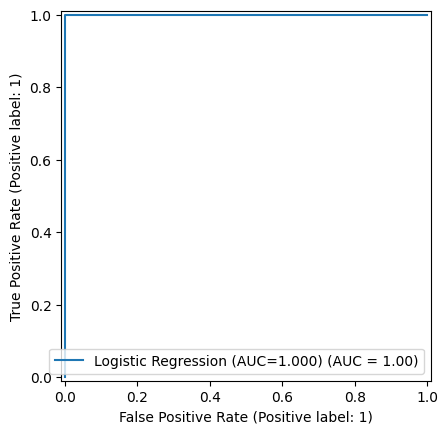

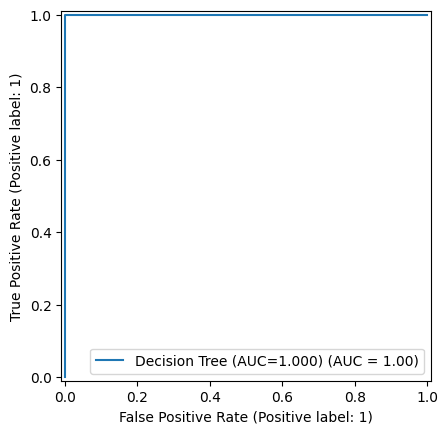

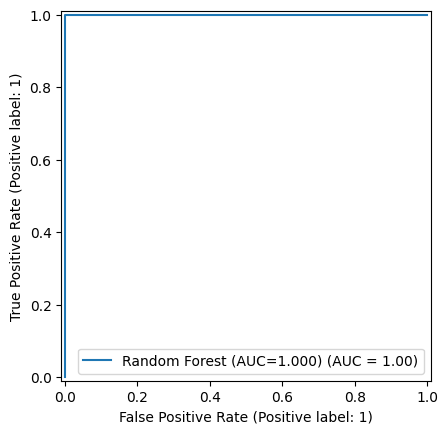

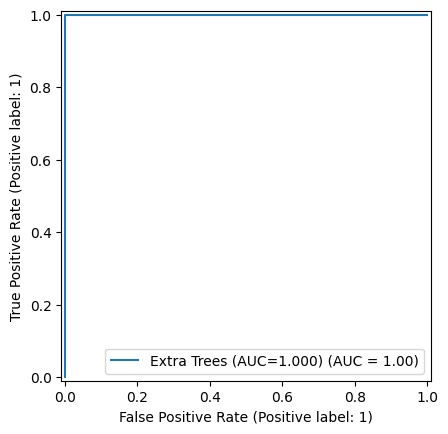

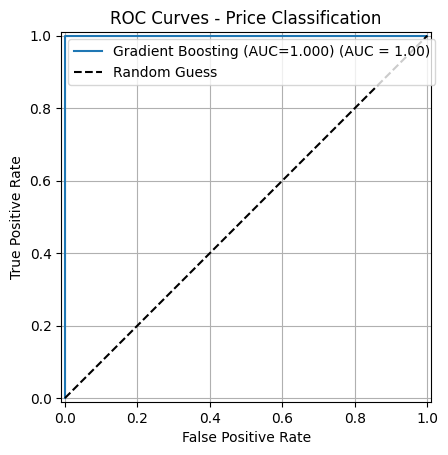


FINAL MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression       1.0        1.0     1.0       1.0      1.0
      Decision Tree       1.0        1.0     1.0       1.0      1.0
      Random Forest       1.0        1.0     1.0       1.0      1.0
        Extra Trees       1.0        1.0     1.0       1.0      1.0
  Gradient Boosting       1.0        1.0     1.0       1.0      1.0

BEST MODEL:
Model        Logistic Regression
Accuracy                     1.0
Precision                    1.0
Recall                       1.0
F1 Score                     1.0
ROC AUC                      1.0
Name: 0, dtype: object

TOP FEATURES:
                      Feature  Importance
normalized_price_per_quantity    0.532602
                quantity_name    0.130805
           price_per_quantity    0.115055
                 price_amount    0.115051
                 product_name    0.056113
               quantity_value    0.032875
                quantity_

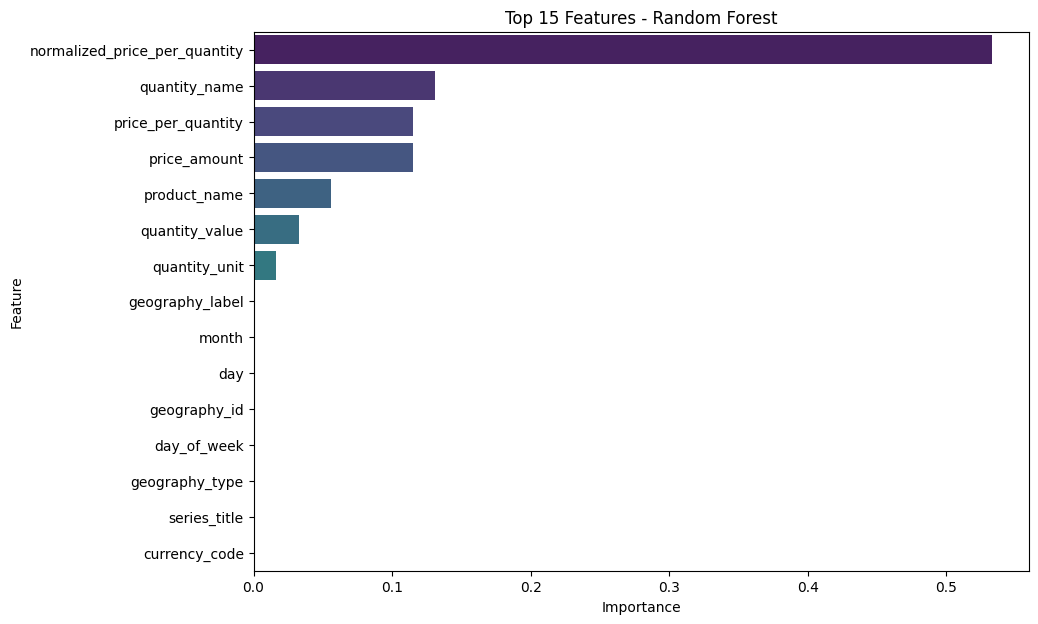

In [14]:
# ==========================================================
# PRICE CLASSIFICATION - TRAIN/TEST + ACCURACY + ROC
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# ==========================================================
# COPY DATA
# ==========================================================

data = df.copy()

# ==========================================================
# DATE FEATURE ENGINEERING
# ==========================================================

data["observed_date"] = pd.to_datetime(
    data["observed_date"],
    errors="coerce"
)

data["year"] = data["observed_date"].dt.year
data["month"] = data["observed_date"].dt.month
data["day"] = data["observed_date"].dt.day
data["day_of_week"] = data["observed_date"].dt.dayofweek

# ==========================================================
# NUMERICAL FEATURE ENGINEERING
# ==========================================================

data["price_per_quantity"] = (
    data["price_amount"] /
    (data["quantity_value"] + 1e-6)
)

data["normalized_price_per_quantity"] = (
    data["normalized_price_amount"] /
    (data["normalized_quantity_value"] + 1e-6)
)

# ==========================================================
# REMOVE IDENTIFIER / URL COLUMNS
# ==========================================================

drop_cols = [
    "series_id",
    "canonical_url",
    "observed_date",
    "normalized_price_amount"
]

data = data.drop(
    columns=drop_cols,
    errors="ignore"
)

# ==========================================================
# CREATE BINARY TARGET
# ==========================================================
# 1 = High price
# 0 = Low price

price_threshold = df["normalized_price_amount"].median()

data["high_price"] = (
    df["normalized_price_amount"] > price_threshold
).astype(int)

# ==========================================================
# FEATURES & TARGET
# ==========================================================

X = data.drop(columns=["high_price"])

y = data["high_price"]

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

# ==========================================================
# CATEGORICAL & NUMERICAL COLUMNS
# ==========================================================

numeric_cols = X_train.select_dtypes(
    include=np.number
).columns

categorical_cols = X_train.select_dtypes(
    exclude=np.number
).columns

# ==========================================================
# HANDLE NUMERICAL MISSING VALUES
# FIT ONLY ON TRAINING DATA
# ==========================================================

num_imputer = SimpleImputer(
    strategy="median"
)

X_train[numeric_cols] = num_imputer.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = num_imputer.transform(
    X_test[numeric_cols]
)

# ==========================================================
# HANDLE CATEGORICAL MISSING VALUES
# ==========================================================

cat_imputer = SimpleImputer(
    strategy="most_frequent"
)

if len(categorical_cols) > 0:

    X_train[categorical_cols] = cat_imputer.fit_transform(
        X_train[categorical_cols]
    )

    X_test[categorical_cols] = cat_imputer.transform(
        X_test[categorical_cols]
    )

# ==========================================================
# LABEL ENCODING
# FIT ONLY ON TRAIN DATA
# ==========================================================

encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    X_train[col] = encoder.fit_transform(
        X_train[col].astype(str)
    )

    mapping = {
        value: index
        for index, value
        in enumerate(encoder.classes_)
    }

    X_test[col] = (
        X_test[col]
        .astype(str)
        .map(mapping)
        .fillna(-1)
        .astype(int)
    )

    encoders[col] = encoder

# ==========================================================
# MODELS
# ==========================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=2000),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42,
            max_depth=10
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}

# ==========================================================
# TRAINING & EVALUATION
# ==========================================================

results = []

plt.figure(figsize=(10, 7))

for name, model in models.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    # ======================================================
    # METRICS
    # ======================================================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC AUC  :", round(roc_auc, 4))

    # ======================================================
    # CLASSIFICATION REPORT
    # ======================================================

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    # ======================================================
    # CONFUSION MATRIX
    # ======================================================

    print("Confusion Matrix:\n")

    print(
        confusion_matrix(
            y_test,
            y_pred
        )
    )

    # ======================================================
    # ROC CURVE
    # ======================================================

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=f"{name} (AUC={roc_auc:.3f})"
    )

    # ======================================================
    # SAVE RESULTS
    # ======================================================

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Guess"
)

plt.title(
    "ROC Curves - Price Classification"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()
plt.grid(True)
plt.show()

# ==========================================================
# MODEL COMPARISON
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print(
    results_df.to_string(index=False)
)

# ==========================================================
# BEST MODEL
# ==========================================================

best_model = results_df.iloc[0]

print("\nBEST MODEL:")
print(best_model)

# ==========================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ==========================================================

rf = models["Random Forest"]

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTOP FEATURES:")
print(
    importance.head(15).to_string(index=False)
)

# ==========================================================
# FEATURE IMPORTANCE VISUALIZATION
# ==========================================================

plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Top 15 Features - Random Forest"
)

plt.show()

## Thanks...........Please Upvote